In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def npg_palette():
    palette = ["#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"]
    return sns.color_palette(palette, len(palette))

dpi = 300
npg = npg_palette()
npg


[(0.9019607843137255, 0.29411764705882354, 0.20784313725490197),
 (0.30196078431372547, 0.7333333333333333, 0.8352941176470589),
 (0.0, 0.6274509803921569, 0.5294117647058824),
 (0.23529411764705882, 0.32941176470588235, 0.5333333333333333),
 (0.9529411764705882, 0.6078431372549019, 0.4980392156862745),
 (0.5176470588235295, 0.5686274509803921, 0.7058823529411765),
 (0.5686274509803921, 0.8196078431372549, 0.7607843137254902),
 (0.8627450980392157, 0.0, 0.0),
 (0.49411764705882355, 0.3803921568627451, 0.2823529411764706),
 (0.6901960784313725, 0.611764705882353, 0.5215686274509804)]

In [159]:
dataname = "params.Nurses_local_int"
clean_name = "Nurses"

# dataname = "params.trauma"
# clean_name = "Trauma Heterogeneous"

# dataname = "params.trauma_shuffled"
# clean_name = "Trauma Homogeneous"

df = pd.read_csv(f"data/summarized/{dataname}.csv", index_col=0)
colors = dict(zip(df["Method"].unique(), npg))

In [160]:
import math

n_hues = len(set(df["Method"]))
n_covs = len(set(df["Covariate"]))

def get_grid_size(n, k=0, fill=False):
    """
    Given interger n, find grid of size l*m = n that comes closest to being a square
    For k > 0,  returns successively "less square" grids
    Retruns (l, m)
    Can be used e.g. for plotting grids
    If fill, prevents pairs of form (1, m) by adding +1 to n
    """
    if n == 1: return (1, 1)
    from sympy import isprime
    if fill and isprime(n): n += 1
    pairs = []
    for i in reversed(range(1, n)):
        rows, cols = 0, 0
        if n % i == 0:
            cols = i
            rows = n // i
            pairs.append((rows, cols))

    pairs = [tuple(sorted(p)) for p in pairs]
    pairs = list(set(pairs))
    pairs = sorted(pairs, key=lambda x: np.abs(x[0] - x[1]))
    try:
        return pairs[k]
    except IndexError:
        return pairs[0]

rows, cols = get_grid_size(n_covs, fill=True)
n_covs, rows, cols

(4, 2, 2)

## Errorbars

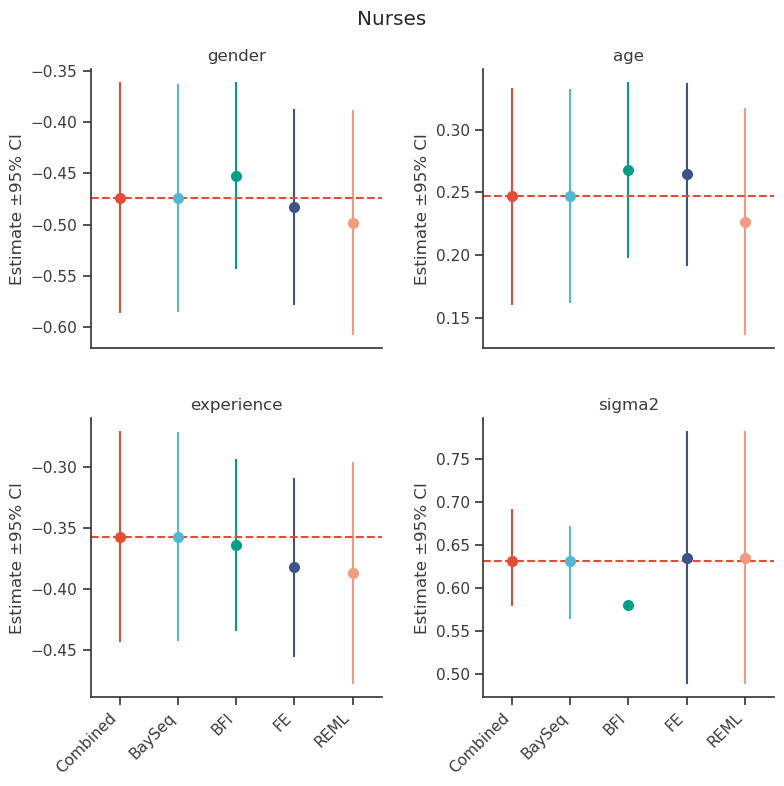

In [161]:
import matplotlib
from matplotlib.ticker import MaxNLocator

matplotlib.rcParams.update({'errorbar.capsize': 2})

# Calculate asymmetric error bars
df['err_low'] = df['Estimate'] - df['lower']
df['err_up'] = df['upper'] - df['Estimate']

grey = "#3A3A3A"

if rows*cols == len(df["Covariate"].unique()):
    covariates = df["Covariate"].unique().reshape(rows, cols)
else:
    covariates = df["Covariate"].unique()
    covariates = np.array(list(covariates) + [None])
    covariates = covariates.reshape(rows, cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4), sharex=True)

for row in range(rows):
    for col in range(cols):

        covariate = covariates[row][col]

        ax = axes[row][col]
        if covariate is None: 
            ax.axis("off")
            continue

        dff = df[df["Covariate"]==covariate]

        sns.set_theme(style="ticks")
        sns.despine()
        #sns.despine(left=True, bottom=True)

        # Plot the points
        sns.stripplot(y='Estimate', x='Method', data=dff, hue="Method", size=8, palette=npg[:n_hues], ax=ax)

        try:
            ax.errorbar(
                y=dff['Estimate'], x=dff['Method'],
                yerr=[dff['err_low'], dff['err_up']], capsize=20, markeredgewidth=10,
                fmt='none', ecolor=colors.values(), linewidth=1.5
            )
        except ValueError:
            # weird error with colors, ignore. but cannot render errobrar caps
            pass

        ref = float(dff[dff["Method"]=="Combined"].loc[:, "Estimate"].values[0])
        ax.axhline(ref, ls="--", color=colors["Combined"])
        ax.set(xlabel=None)
        ax.set_title(covariate, color=grey)
        ax.set_ylabel("Estimate ±95% CI", color=grey)
        
        if row == rows - 1:
            ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.xaxis.set_ticks_position('none') 


        ax.tick_params(color=grey, labelcolor=grey)
        for spine in ax.spines.values():
            spine.set_edgecolor(grey)

        ax.set_xlim(ax.get_xlim())  # why does this add h padding? anyway, it works

        # micro tweaks
        if clean_name == "Nurses" and covariate == "age":
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

fig.suptitle(clean_name)
fig.tight_layout(w_pad=2, h_pad=3)
fig.savefig(f"figures/errorbars.{dataname}.png", dpi=dpi)

## Barplots

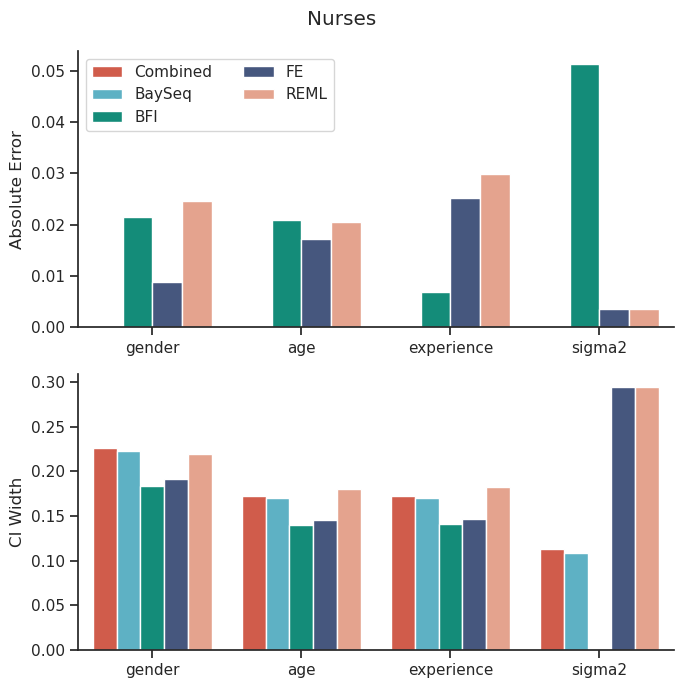

In [162]:
if "Truth_Estimate" not in df.columns:
    df["CI_Size"] = df["upper"] - df["lower"]
    truth = df[df["Method"] == "Combined"][["Covariate", "Estimate"]].rename(columns={"Estimate": "Truth_Estimate"})
    df = df.merge(truth, on="Covariate", how="left")
    df["Error"] = (df["Estimate"] - df["Truth_Estimate"]).abs()


fig, ax = plt.subplots(2, 1, figsize=(7, 7))
sns.despine()

sns.barplot(data=df[df["Method"]!="Combined"], x="Covariate", y="Error", hue="Method", palette=colors, ax=ax[0])
ax[0].set_ylabel("Absolute Error")

sns.barplot(data=df, x="Covariate", y="CI_Size", hue="Method", palette=colors, ax=ax[1])
ax[1].set_ylabel("CI Width")

handles, labels = ax[1].get_legend_handles_labels()
ax[0].legend(handles, labels, ncols=2)
ax[1].legend([], [], framealpha=0)
#ax[1].legend(title=None, ncols=2)

for a in ax:
    a.set_xlabel(None)

fig.suptitle(clean_name)
fig.tight_layout()
fig.savefig(f"figures/bars.{dataname}.png", dpi=dpi)

## Nurses

/tmp/ipykernel_30519/2882379499.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=2, h_pad=2)


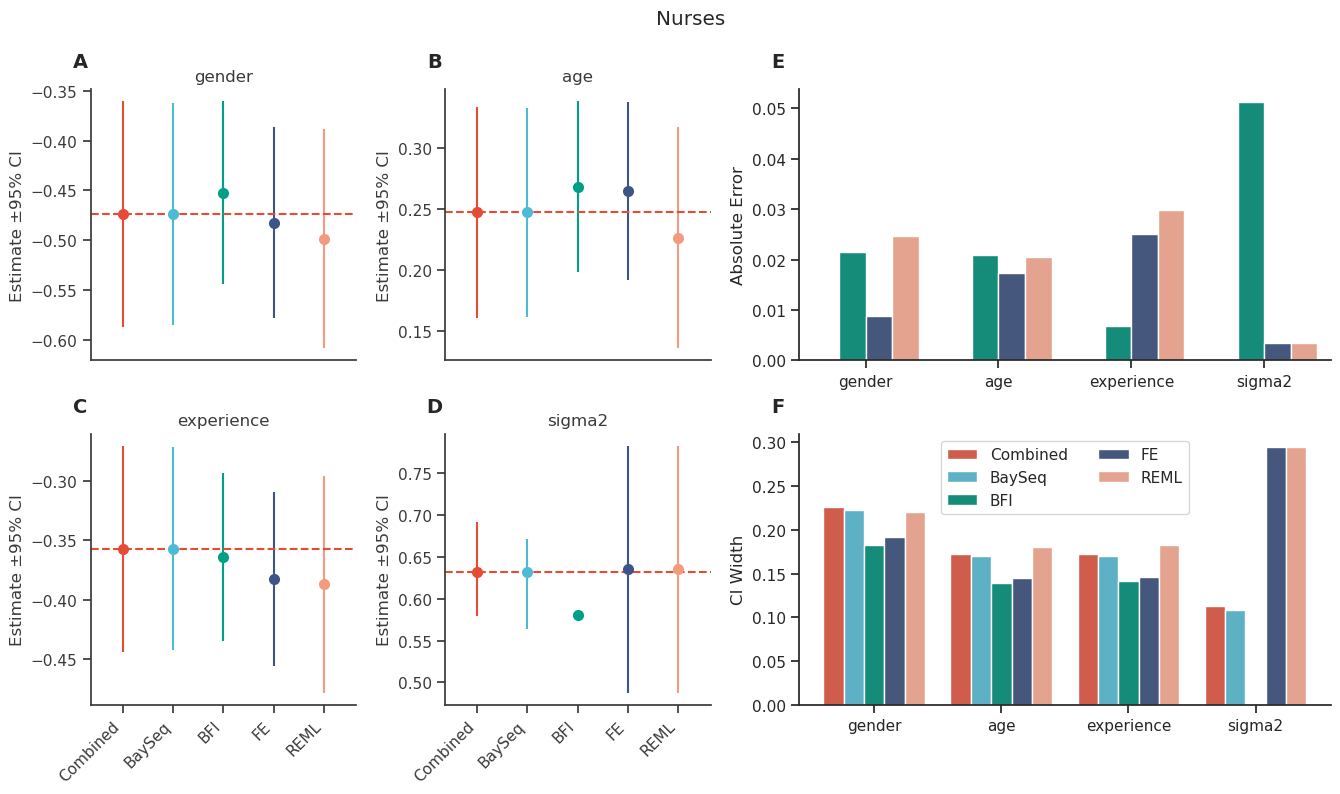

In [164]:
import matplotlib
from matplotlib.ticker import MaxNLocator

matplotlib.rcParams.update({'errorbar.capsize': 2})

# Calculate asymmetric error bars
df['err_low'] = df['Estimate'] - df['lower']
df['err_up'] = df['upper'] - df['Estimate']

grey = "#3A3A3A"

if rows*cols == len(df["Covariate"].unique()):
    covariates = df["Covariate"].unique().reshape(rows, cols)
else:
    covariates = df["Covariate"].unique()
    covariates = np.array(list(covariates) + [None])
    covariates = covariates.reshape(rows, cols)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False,
                         gridspec_kw={'width_ratios': [1, 1, 2], 'hspace': 0.27,'wspace':0.25})

for row in range(rows):
    for col in range(cols):

        covariate = covariates[row][col]

        ax = axes[row][col]
        if covariate is None: 
            ax.axis("off")
            continue

        dff = df[df["Covariate"]==covariate]

        sns.set_theme(style="ticks")
        sns.despine()
        #sns.despine(left=True, bottom=True)

        # Plot the points
        sns.stripplot(y='Estimate', x='Method', data=dff, hue="Method", size=8, palette=npg[:n_hues], ax=ax)

        try:
            ax.errorbar(
                y=dff['Estimate'], x=dff['Method'],
                yerr=[dff['err_low'], dff['err_up']], capsize=20, markeredgewidth=10,
                fmt='none', ecolor=colors.values(), linewidth=1.5
            )
        except ValueError:
            # weird error with colors, ignore. but cannot render errobrar caps
            pass

        ref = float(dff[dff["Method"]=="Combined"].loc[:, "Estimate"].values[0])
        ax.axhline(ref, ls="--", color=colors["Combined"])
        ax.set(xlabel=None)
        ax.set_title(covariate, color=grey)
        ax.set_ylabel("Estimate ±95% CI", color=grey)
        
        if row == rows - 1:
            ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.xaxis.set_ticks([])


        ax.tick_params(color=grey, labelcolor=grey)
        for spine in ax.spines.values():
            spine.set_edgecolor(grey)

        xlim = ax.get_xlim()
        offset = 0.1*(xlim[1]-xlim[0])
        ax.set_xlim(xlim[0]-offset, xlim[1]+offset)

        # micro tweaks
        if clean_name == "Nurses" and covariate == "age":
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))



axes2 = axes[:, 2]

sns.barplot(data=df[df["Method"]!="Combined"], x="Covariate", y="Error", hue="Method", palette=colors, ax=axes2[0])
axes2[0].set_ylabel("Absolute Error")

sns.barplot(data=df, x="Covariate", y="CI_Size", hue="Method", palette=colors, ax=axes2[1])
axes2[1].set_ylabel("CI Width")
axes2[1].set_ylim(0, 1.05*np.max(df["CI_Size"]))

handles, labels = axes2[1].get_legend_handles_labels()
axes2[1].legend(handles, labels, ncols=2)
axes2[0].legend([], [], framealpha=0)

for a in axes2:
    a.set_xlabel(None)

flataxes = axes.flatten()
# for i in range(len(flataxes)):
#     flataxes[i].annotate(chr(ord('A')+i), xy=(-0.04, 1.1),
#                xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[0].annotate("A", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[1].annotate("B", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[2].annotate("E", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[3].annotate("C", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[4].annotate("D", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
flataxes[5].annotate("F", xy=(-0.04, 1.1), xycoords="axes fraction", va='center',ha='center', weight="bold", fontsize=14)
                     
axes[-1][-1].plot(1,1)
fig.suptitle(clean_name)
fig.tight_layout(w_pad=2, h_pad=2)
fig.savefig(f"figures/collage.{dataname}.pdf", dpi=dpi, bbox_inches="tight")